# Capstone Project I — Mutual Fund Analytics
## Day 4: Fund Performance Analytics
**Intern Name:** Anvesh Tammineni  
**Date:** June 29, 2026  

This notebook calculates advanced risk-adjusted performance metrics, builds a composite scorecard ranking the 40 mutual fund schemes, calculates Alpha/Beta coefficients and Maximum Drawdowns, and compares the top 5 performing funds against the Nifty 50 and Nifty 100 benchmarks.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Output directories
IMAGE_DIR = "../reports/images"
os.makedirs(IMAGE_DIR, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("Setup complete.")

Setup complete.


In [2]:
nav_df = pd.read_csv("../data/processed/02_nav_history.csv")
master_df = pd.read_csv("../data/processed/01_fund_master.csv")
bench_df = pd.read_csv("../data/processed/10_benchmark_indices.csv")
perf_df = pd.read_csv("../data/processed/07_scheme_performance.csv")
print("All required processed datasets loaded successfully.")

All required processed datasets loaded successfully.


### 1. Compute & Validate Daily Returns
Calculate daily returns: $daily\_return = \frac{nav_t}{nav_{t-1}} - 1$ for all 40 schemes and plot returns distribution for sample schemes.

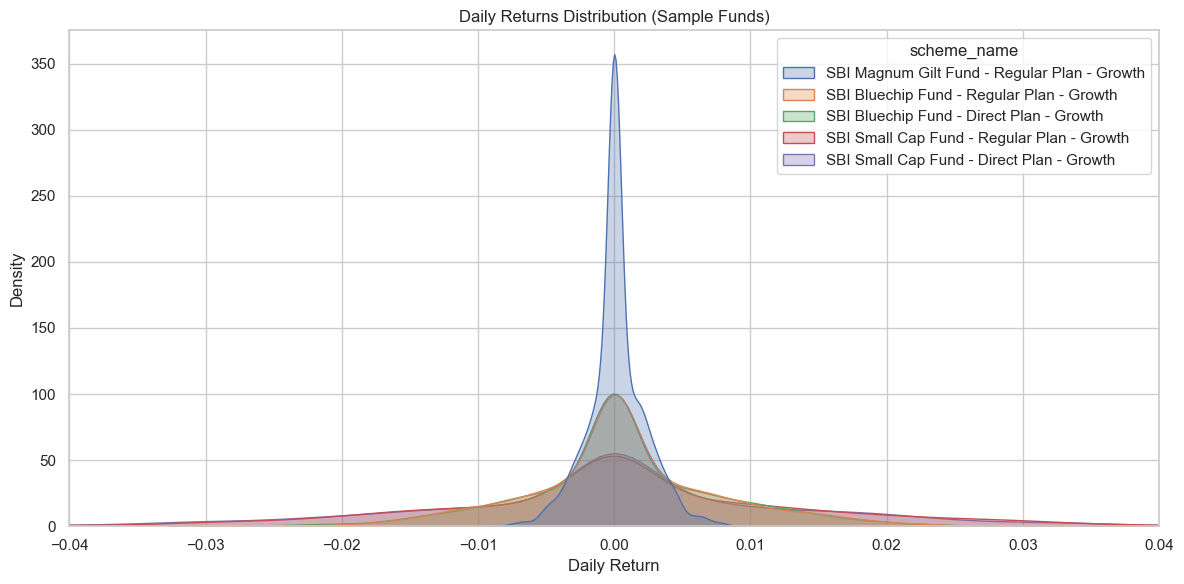

Returns validation complete. Standard distribution looks normal near-zero mean.


In [3]:
nav_df['date'] = pd.to_datetime(nav_df['date'])
nav_df = nav_df.sort_values(by=['amfi_code', 'date'])
nav_df['daily_return'] = nav_df.groupby('amfi_code')['nav'].pct_change()

# Select 5 sample funds to plot distributions
sample_codes = master_df['amfi_code'].head(5).tolist()
sample_returns = nav_df[nav_df['amfi_code'].isin(sample_codes)].merge(master_df[['amfi_code', 'scheme_name']], on='amfi_code')

plt.figure(figsize=(12, 6))
sns.kdeplot(data=sample_returns, x='daily_return', hue='scheme_name', fill=True, common_norm=False, alpha=0.3)
plt.title("Daily Returns Distribution (Sample Funds)")
plt.xlabel("Daily Return")
plt.ylabel("Density")
plt.xlim(-0.04, 0.04)
plt.tight_layout()
plt.savefig("../reports/images/daily_returns_distribution.png", dpi=150)
plt.show()

print("Returns validation complete. Standard distribution looks normal near-zero mean.")

### 2. Compute Trailing CAGR
Calculate Compound Annual Growth Rate (CAGR) for 1-Year and 3-Year periods. For 5-Year period, since the dataset spans 4.4 years, we calculate the Full Period CAGR from 2022 to 2026.

In [4]:
max_date = nav_df['date'].max()
date_1yr_ago = max_date - pd.DateOffset(years=1)
date_3yr_ago = max_date - pd.DateOffset(years=3)
date_start = nav_df['date'].min()

all_dates = nav_df['date'].unique()
def get_closest_date(target, dates):
    return min(dates, key=lambda x: abs(x - target))

date_1yr_actual = get_closest_date(date_1yr_ago, all_dates)
date_3yr_actual = get_closest_date(date_3yr_ago, all_dates)

cagr_list = []
for amfi, group in nav_df.groupby('amfi_code'):
    group = group.set_index('date')
    nav_end = group.loc[max_date, 'nav']
    nav_1yr_start = group.loc[date_1yr_actual, 'nav']
    nav_3yr_start = group.loc[date_3yr_actual, 'nav']
    nav_start = group.loc[date_start, 'nav']
    
    cagr_1yr = (nav_end / nav_1yr_start) - 1.0
    cagr_3yr = (nav_end / nav_3yr_start) ** (1.0 / 3.0) - 1.0
    
    years_full = (max_date - date_start).days / 365.25
    cagr_full = (nav_end / nav_start) ** (1.0 / years_full) - 1.0
    
    cagr_list.append({
        "amfi_code": amfi,
        "cagr_1yr": cagr_1yr,
        "cagr_3yr": cagr_3yr,
        "cagr_full_period": cagr_full
    })
    
cagr_df = pd.DataFrame(cagr_list)
print("CAGR values computed. Head of CAGR Comparison table:")
print(cagr_df.head())


CAGR values computed. Head of CAGR Comparison table:
   amfi_code  cagr_1yr  cagr_3yr  cagr_full_period
0     100016 -0.022243  0.012926          0.026371
1     100025  0.037050  0.039164          0.044582
2     100033  0.532324  0.324425          0.301232
3     101206  0.479241  0.289677          0.235384
4     101207 -0.239860 -0.041524          0.079388


### 3. Compute Risk-Adjusted Return Ratios
Calculate annualized **Sharpe Ratio** and **Sortino Ratio** using risk-free rate of $6.5\%$ ($Rf_{daily} = 6.5\%/252$).

In [5]:
rf = 0.065
daily_rf = rf / 252.0

ratios_list = []
for amfi, group in nav_df.groupby('amfi_code'):
    returns = group['daily_return'].dropna()
    mean_ret = returns.mean()
    std_ret = returns.std()
    
    sharpe = (mean_ret - daily_rf) / std_ret * np.sqrt(252) if std_ret > 0 else 0
    
    downside_returns = returns[returns < 0]
    downside_std = downside_returns.std() if len(downside_returns) > 0 else std_ret
    sortino = (mean_ret - daily_rf) / downside_std * np.sqrt(252) if downside_std > 0 else 0
    
    ratios_list.append({
        "amfi_code": amfi,
        "mean_daily_return": mean_ret,
        "std_daily_return": std_ret,
        "sharpe_ratio": sharpe,
        "sortino_ratio": sortino
    })
    
ratios_df = pd.DataFrame(ratios_list)
print("Sharpe and Sortino ratios computed and ranked.")
print(ratios_df.head())


Sharpe and Sortino ratios computed and ranked.
   amfi_code  mean_daily_return  std_daily_return  sharpe_ratio  sortino_ratio
0     100016           0.000101          0.007749     -0.321019      -0.472822
1     100025           0.000122          0.002081     -1.039941      -1.461220
2     100033           0.000772          0.010097      0.808268       1.144216
3     101206           0.000609          0.007768      0.717409       1.063909
4     101207           0.000303          0.013741      0.052618       0.075668


### 4. Alpha & Beta Regression on Nifty 100
Run OLS linear regression of fund daily returns against NIFTY100 daily returns using `scipy.stats.linregress`. Export results to `alpha_beta.csv`.

In [6]:
nifty100 = bench_df[bench_df['index_name'] == 'NIFTY100'].copy()
nifty100['date'] = pd.to_datetime(nifty100['date'])
nifty100 = nifty100.sort_values(by='date')
nifty100['nifty100_return'] = nifty100['close_value'].pct_change()
nifty100_clean = nifty100[['date', 'nifty100_return']].dropna()

reg_list = []
for amfi, group in nav_df.groupby('amfi_code'):
    merged = group.merge(nifty100_clean, on='date').dropna(subset=['daily_return', 'nifty100_return'])
    if len(merged) > 10:
        slope, intercept, r_val, p_val, std_err = stats.linregress(merged['nifty100_return'], merged['daily_return'])
        alpha = intercept * 252
        beta = slope
    else:
        alpha, beta = 0, 1.0
    reg_list.append({
        "amfi_code": amfi,
        "alpha": alpha,
        "beta": beta
    })
    
reg_df = pd.DataFrame(reg_list)
reg_df.to_csv("../alpha_beta.csv", index=False)
print("Alpha and Beta coefficients successfully exported to alpha_beta.csv. Summary:")
print(reg_df.head())


Alpha and Beta coefficients successfully exported to alpha_beta.csv. Summary:
   amfi_code     alpha      beta
0     100016  0.037476 -0.058268
1     100025  0.042818  0.001158
2     100033  0.271954  0.005104
3     101206  0.213998  0.021086
4     101207  0.108971 -0.065289


### 5. Maximum Drawdown & Date Range Analysis
Calculate maximum drawdown: $min(\frac{NAV}{running\_max} - 1)$ for each fund, and identify the worst Peak-to-Trough drawdown date ranges and recovery dates.

In [7]:
dd_list = []
for amfi, group in nav_df.groupby('amfi_code'):
    group = group.sort_values(by='date').reset_index(drop=True)
    navs = group['nav']
    running_max = navs.cummax()
    drawdowns = navs / running_max - 1.0
    max_dd = drawdowns.min()
    
    trough_idx = drawdowns.idxmin()
    trough_date = group.loc[trough_idx, 'date']
    
    peak_val = running_max.loc[trough_idx]
    peak_df = group[(group['date'] <= trough_date) & (group['nav'] == peak_val)]
    peak_date = peak_df['date'].max() if not peak_df.empty else group.loc[group['nav'].idxmax(), 'date']
    
    recovery_df = group[(group['date'] > trough_date) & (group['nav'] >= peak_val)]
    recovery_date = recovery_df.iloc[0]['date'] if not recovery_df.empty else "Not Recovered"
    
    dd_list.append({
        "amfi_code": amfi,
        "max_drawdown": max_dd,
        "worst_drawdown_peak_date": peak_date.strftime('%Y-%m-%d'),
        "worst_drawdown_trough_date": trough_date.strftime('%Y-%m-%d'),
        "worst_drawdown_recovery_date": recovery_date.strftime('%Y-%m-%d') if isinstance(recovery_date, pd.Timestamp) else recovery_date
    })
    
dd_df = pd.DataFrame(dd_list)
print("Drawdown analysis complete. worst drawdown ranges mapped:")
print(dd_df.head())


Drawdown analysis complete. worst drawdown ranges mapped:
   amfi_code  max_drawdown worst_drawdown_peak_date  \
0     100016     -0.247344               2022-03-30   
1     100025     -0.043083               2023-05-23   
2     100033     -0.162172               2022-03-13   
3     101206     -0.112916               2023-04-24   
4     101207     -0.354469               2024-11-21   

  worst_drawdown_trough_date worst_drawdown_recovery_date  
0                 2022-09-15                   2023-03-14  
1                 2023-07-28                   2024-01-30  
2                 2022-05-12                   2022-07-27  
3                 2023-07-05                   2023-09-28  
4                 2026-05-11                Not Recovered  


### 6. Fund Scorecard (0 - 100)
Compile a composite scorecard score based on:
- $30\% \times$ 3yr Return Rank
- $25\% \times$ Sharpe Ratio Rank
- $20\% \times$ Alpha Rank
- $15\% \times$ Inverse Expense Ratio Rank
- $10\% \times$ Inverse Max Drawdown Rank

Export scorecard to `fund_scorecard.csv`.

In [8]:
score_df = master_df[['amfi_code', 'scheme_name', 'fund_house', 'expense_ratio_pct']].copy()
score_df = score_df.merge(cagr_df, on='amfi_code')
score_df = score_df.merge(ratios_df, on='amfi_code')
score_df = score_df.merge(reg_df, on='amfi_code')
score_df = score_df.merge(dd_df, on='amfi_code')

# Percentile ranks
score_df['rank_3yr'] = score_df['cagr_3yr'].rank(pct=True) * 100
score_df['rank_sharpe'] = score_df['sharpe_ratio'].rank(pct=True) * 100
score_df['rank_alpha'] = score_df['alpha'].rank(pct=True) * 100
score_df['rank_expense'] = score_df['expense_ratio_pct'].rank(ascending=False, pct=True) * 100
score_df['rank_dd'] = score_df['max_drawdown'].rank(pct=True) * 100 # less negative is higher rank

# Weighted Score
score_df['scorecard_score'] = (
    0.30 * score_df['rank_3yr'] +
    0.25 * score_df['rank_sharpe'] +
    0.20 * score_df['rank_alpha'] +
    0.15 * score_df['rank_expense'] +
    0.10 * score_df['rank_dd']
)

score_df['scorecard_rank'] = score_df['scorecard_score'].rank(ascending=False, method='min')
score_df_sorted = score_df.sort_values(by='scorecard_rank')
score_df_sorted.to_csv("../fund_scorecard.csv", index=False)
print("Scorecard calculated. Top 5 schemes:")
print(score_df_sorted[['scheme_name', 'scorecard_score', 'scorecard_rank']].head(5))


Scorecard calculated. Top 5 schemes:
                                          scheme_name  scorecard_score  \
34      Mirae Asset Large Cap Fund - Regular - Growth           86.250   
12           ICICI Pru Midcap Fund - Regular - Growth           82.875   
22             Kotak Flexicap Fund - Regular - Growth           82.000   
7   HDFC Mid-Cap Opportunities Fund - Regular - Gr...           80.750   
11          ICICI Pru Bluechip Fund - Direct - Growth           79.375   

    scorecard_rank  
34             1.0  
12             2.0  
22             3.0  
7              4.0  
11             5.0  


### 7. Benchmark Comparison & Tracking Error
Compare rebased NAV trajectories of the top 5 scorecard funds vs Nifty 50 and Nifty 100 benchmarks over a 3-year window. Compute daily tracking error: $TE = Std(Rp - Rb) \times \sqrt{252}$ against Nifty 100.

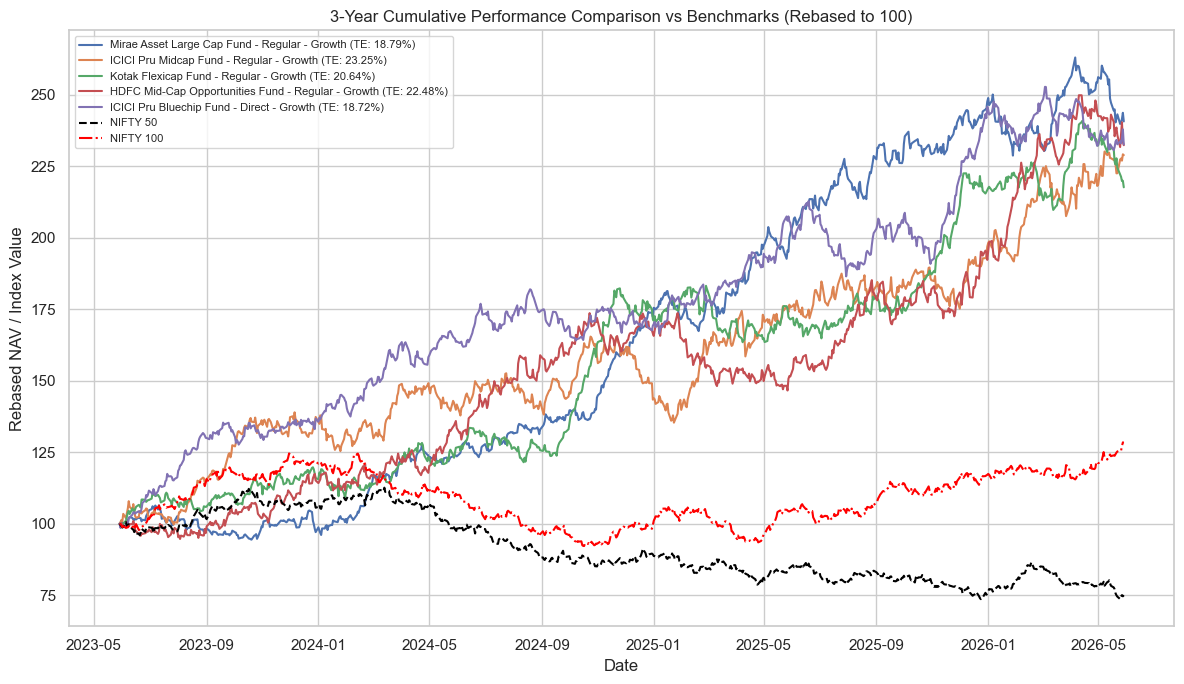

Benchmark comparison plot successfully exported to reports/images/benchmark_comparison.png


In [9]:
top_5 = score_df_sorted.head(5)
top_5_codes = top_5['amfi_code'].tolist()
top_5_names = top_5['scheme_name'].tolist()

start_3yr = max_date - pd.DateOffset(years=3)
nav_3yr = nav_df[(nav_df['amfi_code'].isin(top_5_codes)) & (nav_df['date'] >= start_3yr)].copy()

bench_3yr = bench_df[(bench_df['index_name'].isin(['NIFTY50', 'NIFTY100'])) & (pd.to_datetime(bench_df['date']) >= start_3yr)].copy()
bench_3yr['date'] = pd.to_datetime(bench_3yr['date'])

nav_pivot = nav_3yr.pivot(index='date', columns='amfi_code', values='nav')
bench_pivot = bench_3yr.pivot(index='date', columns='index_name', values='close_value')

merged_3yr = nav_pivot.merge(bench_pivot, left_index=True, right_index=True, how='inner')
rebased = merged_3yr.div(merged_3yr.iloc[0]) * 100.0

# Calculate tracking errors
nifty100_ret = merged_3yr['NIFTY100'].pct_change().dropna()
te_results = {}
for code in top_5_codes:
    fund_ret = merged_3yr[code].pct_change().dropna()
    aligned = pd.DataFrame({'fund': fund_ret, 'bench': nifty100_ret}).dropna()
    te = np.std(aligned['fund'] - aligned['bench']) * np.sqrt(252)
    te_results[code] = te

# Plotting
plt.figure(figsize=(12, 7))
for code, name in zip(top_5_codes, top_5_names):
    plt.plot(rebased.index, rebased[code], label=f"{name} (TE: {te_results[code]*100:.2f}%)")
    
plt.plot(rebased.index, rebased['NIFTY50'], label="NIFTY 50", color='black', linestyle='--')
plt.plot(rebased.index, rebased['NIFTY100'], label="NIFTY 100", color='red', linestyle='-.')

plt.title("3-Year Cumulative Performance Comparison vs Benchmarks (Rebased to 100)")
plt.xlabel("Date")
plt.ylabel("Rebased NAV / Index Value")
plt.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("../reports/images/benchmark_comparison.png", dpi=150)
plt.show()
print("Benchmark comparison plot successfully exported to reports/images/benchmark_comparison.png")